# Load dataset

In [40]:
import pandas as pd
import numpy as np
import datetime
import os

import matplotlib.pyplot as plt
import seaborn as sns

file_path = "dfTransjakarta.csv"
if not os.path.exists(file_path):
    print(f"Error: {file_path} not found.")
    exit(1)

df = pd.read_csv(file_path)
print(f"Original shape: {df.shape}")

Original shape: (37900, 22)


# Dataframe info

In [41]:
df.head()

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,106.84402,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,106.83302,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,106.81435,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,106.93526,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,106.88900,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37900 entries, 0 to 37899
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transID           37900 non-null  object 
 1   payCardID         37900 non-null  int64  
 2   payCardBank       37900 non-null  object 
 3   payCardName       37900 non-null  object 
 4   payCardSex        37900 non-null  object 
 5   payCardBirthDate  37900 non-null  int64  
 6   corridorID        36643 non-null  object 
 7   corridorName      35970 non-null  object 
 8   direction         37900 non-null  float64
 9   tapInStops        36687 non-null  object 
 10  tapInStopsName    37900 non-null  object 
 11  tapInStopsLat     37900 non-null  float64
 12  tapInStopsLon     37900 non-null  float64
 13  stopStartSeq      37900 non-null  int64  
 14  tapInTime         37900 non-null  object 
 15  tapOutStops       35611 non-null  object 
 16  tapOutStopsName   36556 non-null  object

In [43]:
df['payCardBank'].unique()

array(['emoney', 'dki', 'flazz', 'online', 'brizzi', 'bni'], dtype=object)

In [44]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Non-Null': df.notnull().sum(),
    'Null': df.isnull().sum(),
    'Dtype': df.dtypes
})

summary

,Column,Non-Null,Null,Dtype
transID,transID,37900,0,object
payCardID,payCardID,37900,0,int64
payCardBank,payCardBank,37900,0,object
payCardName,payCardName,37900,0,object
payCardSex,payCardSex,37900,0,object
payCardBirthDate,payCardBirthDate,37900,0,int64
corridorID,corridorID,36643,1257,object
corridorName,corridorName,35970,1930,object
direction,direction,37900,0,float64
tapInStops,tapInStops,36687,1213,object


# Cleaning data

In [45]:
# 2. Convert Datetime
df['tapInTime'] = pd.to_datetime(df['tapInTime'], errors='coerce')
df['tapOutTime'] = pd.to_datetime(df['tapOutTime'], errors='coerce')

# pisah tahun bulan, tanggal, jam dan menit pada tapInTime dan tapOutTime
df['tapInYear'] = df['tapInTime'].dt.year
df['tapInMonth'] = df['tapInTime'].dt.month
df['tapInDate'] = df['tapInTime'].dt.day
df['tapInHour'] = df['tapInTime'].dt.hour
df['tapInMinute'] = df['tapInTime'].dt.minute

df['tapOutYear'] = df['tapOutTime'].dt.year
df['tapOutMonth'] = df['tapOutTime'].dt.month
df['tapOutDate'] = df['tapOutTime'].dt.day
df['tapOutHour'] = df['tapOutTime'].dt.hour
df['tapOutMinute'] = df['tapOutTime'].dt.minute

# 3. Handle Missing Values
# Drop rows where essential information (like tapInStops or tapInTime) is missing
df = df.dropna(subset=['tapInStopsName', 'tapInTime'])

# Featutre enggineering

In [46]:
# Calculate Trip Duration in minutes
df['trip_duration_mins'] = (df['tapOutTime'] - df['tapInTime']).dt.total_seconds() / 60.0

# Fill negative or NaN durations with median, or drop them. Let's drop them for cleaner analysis.
df = df[(df['trip_duration_mins'] > 0) & (df['trip_duration_mins'] < 300) | (df['trip_duration_mins'].isna())]

# Extract Hour and Day of Week
df['tapInDayOfWeek'] = df['tapInTime'].dt.dayofweek # 0=Monday, 6=Sunday
df['tapInDayName'] = df['tapInTime'].dt.day_name()

# Handle Outliers in payAmount
# Assume normal payAmount is between 0 and 20000
df = df[(df['payAmount'] >= 0) & (df['payAmount'] <= 20000) | (df['payAmount'].isna())]

# Handle Birth Date / Age
current_year = df['tapInTime'].dt.year.max()
if pd.isna(current_year):
    current_year = 2023 # default

df['payCardBirthDate'] = pd.to_numeric(df['payCardBirthDate'], errors='coerce')
df['age'] = current_year - df['payCardBirthDate']
# Filter impossible ages
df.loc[(df['age'] < 5) | (df['age'] > 100), 'age'] = np.nan

# save clean dataset

In [47]:
cleaned_file = "dfTransjakarta_cleaned.csv"
df.to_csv(cleaned_file, index=False)
print(f"Cleaned dataset saved to {cleaned_file}. Shape: {df.shape}")

Cleaned dataset saved to dfTransjakarta_cleaned.csv. Shape: (37900, 36)


# visualisasi

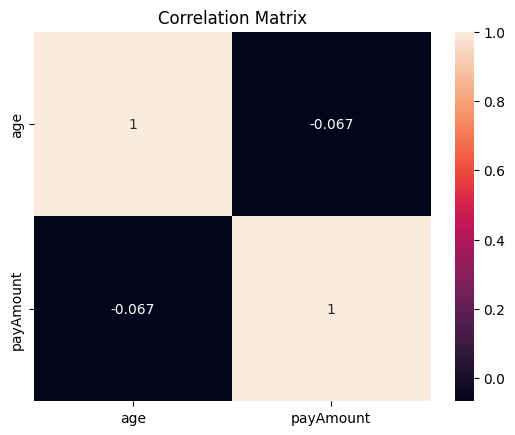

In [ ]:
num_cols = ['age', 'payAmount']   # payCardBank walau setelah di onehot encoder tetep ga bisa cik karena datanya bool dan aku masi belum nemu solusi

# Corelation Matrix
plt.figure()
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

# Nyiapin buat predict kepadatan penumpang di hari dan jam tertentu

In [49]:
# Group by Stop Name, Day of Week, and Hour
density_df = df.groupby(['tapInStopsName', 'tapInDayOfWeek', 'tapInHour']).size().reset_index(name='passenger_count')

density_file = "density_data.csv"
density_df.to_csv(density_file, index=False)
print(f"Density data saved to {density_file}. Shape: {density_df.shape}")

print("Data Pipeline Completed Successfully!")

Density data saved to density_data.csv. Shape: (23364, 4)
Data Pipeline Completed Successfully!
